# Exploration of R3D data computed with full polarisation matrices in kappa

## Extra codes

### Create gas-kappa-file with empty scatmat-matrix

In [ ]:
# Write empty kappascatmat-file for usage for gas
# or other medium with no scattering.

import analyze_polarization_functions as apf
apf.write_r3d_emptypolarization()


### Remove spikes from images

In [ ]:
import os

folder = '../r3dresults_vltcompare/st28gm06n052'
phase = '166'
nseed = 1

imagefiles = []
for filename in os.listdir(f'{folder}_{nseed}/{phase}/'):
    if filename.split('_')[0] == 'image':
        imagefiles.append(filename)

print(len(imagefiles))

imagefiles2 = [imagefile for imagefile in os.listdir(f'{folder}_{nseed}/{phase}/') if imagefile.split('_')[0] == 'image']
print(imagefiles2)
print(len(imagefiles2))





12
['image_i180_phi000_0.82um.out', 'image_i090_phi270_0.82um.out', 'image_i090_phi000_0.65um.out', 'image_i270_phi000_0.82um.out', 'image_i090_phi090_0.82um.out', 'image_i090_phi270_0.65um.out', 'image_i000_phi000_0.65um.out', 'image_i090_phi090_0.65um.out', 'image_i270_phi000_0.65um.out', 'image_i180_phi000_0.65um.out', 'image_i000_phi000_0.82um.out', 'image_i090_phi000_0.82um.out']
12


In [ ]:
# TODO
# fix this code

# Remove spikes from Images
import analyze_r3d_functions as a3d
import os

folders = [
    '../r3dresults_vltcompare/st28gm06n052',
    '../r3dresults_vltcompare/st28gm06n074',
    '../r3dresults_vltcompare/st28gm06n075',
]
# Loop over models
for folder in folders:
    # Extract all included snapshot numbers
    phases = [int(filename) for filename in os.listdir(f'{folder}_1') if os.path.isdir(folder+filename)]
    phases.sort()
    # Extract all included image file names
    imagefiles = []
    for filename in os.listdir(f'{folder}_1/{phase}/'):
        if filename.split('_')[0] == 'image':
            imagefiles.append(filename)




# TODO  fix below


for folder,phases in zip(folders,phaseslist):
    print(f'Doing folder: {folder}')
    for phase in phases:
        print(f'  Doing phase {phase:03d}')
        for image in images:

            image1d = a3d.remove_imagespikes(
                folders = [
                    f'{folder}_1/{phase:03d}/',
                    f'{folder}_2/{phase:03d}/',
                    f'{folder}_3/{phase:03d}/',
                    #f'{folder}_4/{phase}/',
                ],
                imagefilename = image
            )
            if os.path.exists(f'{folder}_nospikes/{phase:03d}') == False:
                os.system(f'mkdir {folder}_nospikes/{phase:03d}')
            os.system(f'mv ../{image} {folder}_nospikes/{phase:03d}/')

os.system('spd-say moo')



## Test code for plotting each polarisation component

See Radmc3d-manual for info on polarisation. 

> radmc3d image stokes

Gives image.out-files with 4 columns of pixel data, ie 4 images in each file in the following order:

- I : Total intensity. the incident light
- Q : describes linear polarisation (horizontal or vertical, depending on the sign).
- U : describes polarisation at a 2nd set of orthogonal axes (+/-45 degrees)
- V : describes elliptical polarisation (right-handed if > 0, left-handed < 0)

R3d uses IAU 1974 definition as described in Hamaker & Bregman (1996) A&AS 117, pp.161. (see manual sect 6.9.1 Definitions ...).

All polarised light combines into I via

> I^2 = Q^2 + U^2 + V^2

Only linear polarised light is defined as the complex statement

> L = Q + iU

so that the absolute is (ie the INTENSITY of the LINEAR polarised light)

> |L| = sqrt(Q^2 + U^2)

and the INTENSITY of the CIRCULAR polarised light is simply

> |V| = sqrt(V^2)


All total fluxes: [3.7732592735724554e-87, 2.6582646561844043e-86, 5.728627558311734e-84, 0.0, 0.0, 4.428064210559612e-86]


/tmp/ipykernel_43638/2602706159.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


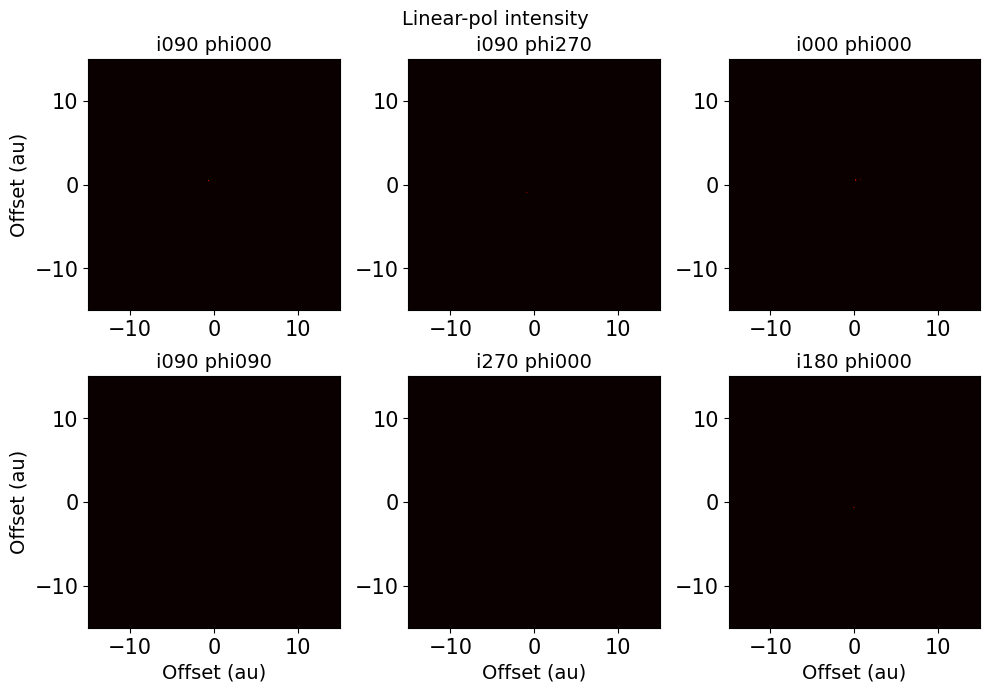

In [5]:
# Plot all images of one polarization and at one snapshot
# and one wavelenght only
#
import analyze_polarization_functions as apf
fig,ax,fluxtotal = apf.plot_onepolarization(
    imagepath='../r3dresults_vltcompare/st28gm06n052_nospikes/166_optoolmgsio/',
    imagewave=0.65,
    #polarization='i',
    polarization='l',
    #polarization='v',
    vmaxcorr=1
)
print(f'All total fluxes: {fluxtotal}')
fig.set_figheight(7)
fig.set_figwidth(10)
fig.tight_layout()
fig.subplots_adjust(top=0.92)
fig.show()

/tmp/ipykernel_43915/2843569559.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


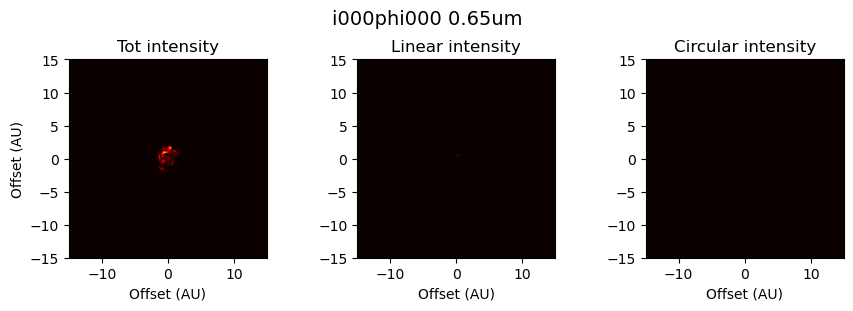

In [1]:
# Plot all polarizations of one angle
# one snapshot, one wavelength
# 
import analyze_polarization_functions as apf
fig,ax = apf.plot_allpolarizations(
    imagepath='../r3dresults_vltcompare/st28gm06n052_nospikes/166_optoolmgsio/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1
)
fig.tight_layout()
fig.show()